# Crisis Prediction Model Training Pipeline

In [1]:
!pip install --upgrade pip
!pip install -r requirements.txt

# 1. Initialize Configuration & Import custom modules

In [1]:
# Set up Python path
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, ParameterGrid

# Custom modules
from scripts.config import Config
from scripts.data_loader import DataLoader
from scripts.preprocessing import DataPreprocessor
from scripts.feature_engineering import FeatureEngineering
from scripts.feature_importance import FeatureSelector
from scripts.model_architecture import CrisisPredictor
from scripts.training import ModelTrainer
from scripts.evaluation import ModelEvaluator
from scripts.uncertainty import UncertaintyEstimator
from scripts.visualization import Visualizer
from scripts.model_persistence import ModelPersistence

# Initialize configuration
config = Config()
print("Configuration loaded successfully")

2024-11-11 19:05:35.480767: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1731351935.500731   11104 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1731351935.506824   11104 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-11 19:05:35.526828: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Configuration loaded successfully


# 2. Load and Prepare Data

In [2]:
# Force reload the module
import importlib
import scripts.data_loader
importlib.reload(scripts.data_loader)
from scripts.data_loader import DataLoader

# Create new instances
config = Config()
data_loader = DataLoader(config=config)

# Debug prints
print("DataLoader instance:", data_loader)
print("DataLoader __dict__:", data_loader.__dict__)


Initializing DataLoader with config: <scripts.config.Config object at 0x7f5796297dc0>
Config stored in DataLoader: <scripts.config.Config object at 0x7f5796297dc0>
DataLoader instance: <scripts.data_loader.DataLoader object at 0x7f57a793bd00>
DataLoader __dict__: {'_config': <scripts.config.Config object at 0x7f5796297dc0>}


In [3]:
data_loader = DataLoader(config)
df = data_loader.load_data()
train_df, test_df = data_loader.split_temporal(df)
print(f"Training set size: {len(train_df)}, Test set size: {len(test_df)}")

Initializing DataLoader with config: <scripts.config.Config object at 0x7f5796297dc0>
Config stored in DataLoader: <scripts.config.Config object at 0x7f5796297dc0>
Loading data from: /root/ACAPS/src/task-3-modelling/scripts/Combined_Dataset_Experimentation/combined_data.csv


/root/ACAPS/src/task-3-modelling/scripts/data_loader.py:25: DtypeWarning: Columns (25,26,27,28,30,31,33,34,35,56,61,64,69,72,229,232,237,240,245,248,253,256,261,264,269,272,277,280,285,288,292,297,299,302,303,304,322,323,331,332,333,334,338,346,347,348,349,350,351,378) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


Training set size: 10799, Test set size: 2463


# 2.1 Data Visualization and Analysis **(Experimental)**

In [4]:
# Check the structure of targets in config
print("Target specifications:", config.targets)

# Check the actual columns in train_df
print("\nAvailable columns in training data:", train_df.columns.tolist())

# Check a sample of the target variables
for target, specs in config.targets.items():
    print(f"\nTarget: {target}")
    print(f"Columns: {specs['columns']}")
    print("Sample data:")
    print(train_df[specs['columns']].head())

Target specifications: {'severity_level': {'columns': ['Inform Severity Index', 'Inform Severity Category'], 'type': 'regression'}, 'crisis_probability': {'columns': ['Concentration Of Conditions', 'Complexity Of The Crisis', 'Updated_Score'], 'type': 'multiclass'}, 'escalation_risk': {'columns': ['Trend (Last 3 Months)', 'Impact Of The Crisis'], 'type': 'multiclass'}}

Available columns in training data: ['YYYY_MM', 'Crisis Id', 'Crisis', 'Country', 'Iso3', 'Empowerment', 'Bti - Democracy Status', 'Trust In Society', 'Ethnic Fractionalisation', 'Size Of Excluded Ethnic Groups', 'Gender Inequality', 'Income Gini Coefficient', 'Inequality', 'Social Cohesion', 'Conflict Intensity', 'Total Killed In All Crisis', 'Safety And Security', 'Corruption Perception', 'Rule Of Law (Wgi)', 'Rule Of Law (Bti)', 'Freedom In The World', 'Rule Of Law', 'Society And Safety', '# Of Different Types Of Affected Population Groups', 'Diversity Of Groups Affected', 'Impediments To Entry Into Country (Bureaucr

In [5]:
# Check data types for each target
for target, specs in config.targets.items():
    print(f"\nTarget: {target}")
    for col in specs['columns']:
        print(f"\nColumn: {col}")
        print("Data type:", train_df[col].dtype)
        print("Sample values:", train_df[col].head())
        print("Number of unique values:", train_df[col].nunique())
        print("Sample of unique values:", train_df[col].unique()[:5])  # Show first 5 unique values
        print("Value counts:\n", train_df[col].value_counts().head())  # Show top 5 most common values with their counts
        print("-" * 50)


Target: severity_level

Column: Inform Severity Index
Data type: object
Sample values: 0    4.6
1    3.3
2    3.9
3    2.4
4    NaN
Name: Inform Severity Index, dtype: object
Number of unique values: 42
Sample of unique values: ['4.6' '3.3' '3.9' '2.4' nan]
Value counts:
 Inform Severity Index
x      483
3.5    250
3.4    246
2.3    219
3.2    208
Name: count, dtype: int64
--------------------------------------------------

Column: Inform Severity Category
Data type: object
Sample values: 0      5
1      4
2      4
3      3
4    NaN
Name: Inform Severity Category, dtype: object
Number of unique values: 6
Sample of unique values: ['5' '4' '3' nan '2']
Value counts:
 Inform Severity Category
4    1792
3    1745
5     739
2     617
x     483
Name: count, dtype: int64
--------------------------------------------------

Target: crisis_probability

Column: Concentration Of Conditions
Data type: object
Sample values: 0    4
1    3
2    5
3    1
4    2
Name: Concentration Of Conditions, dtype

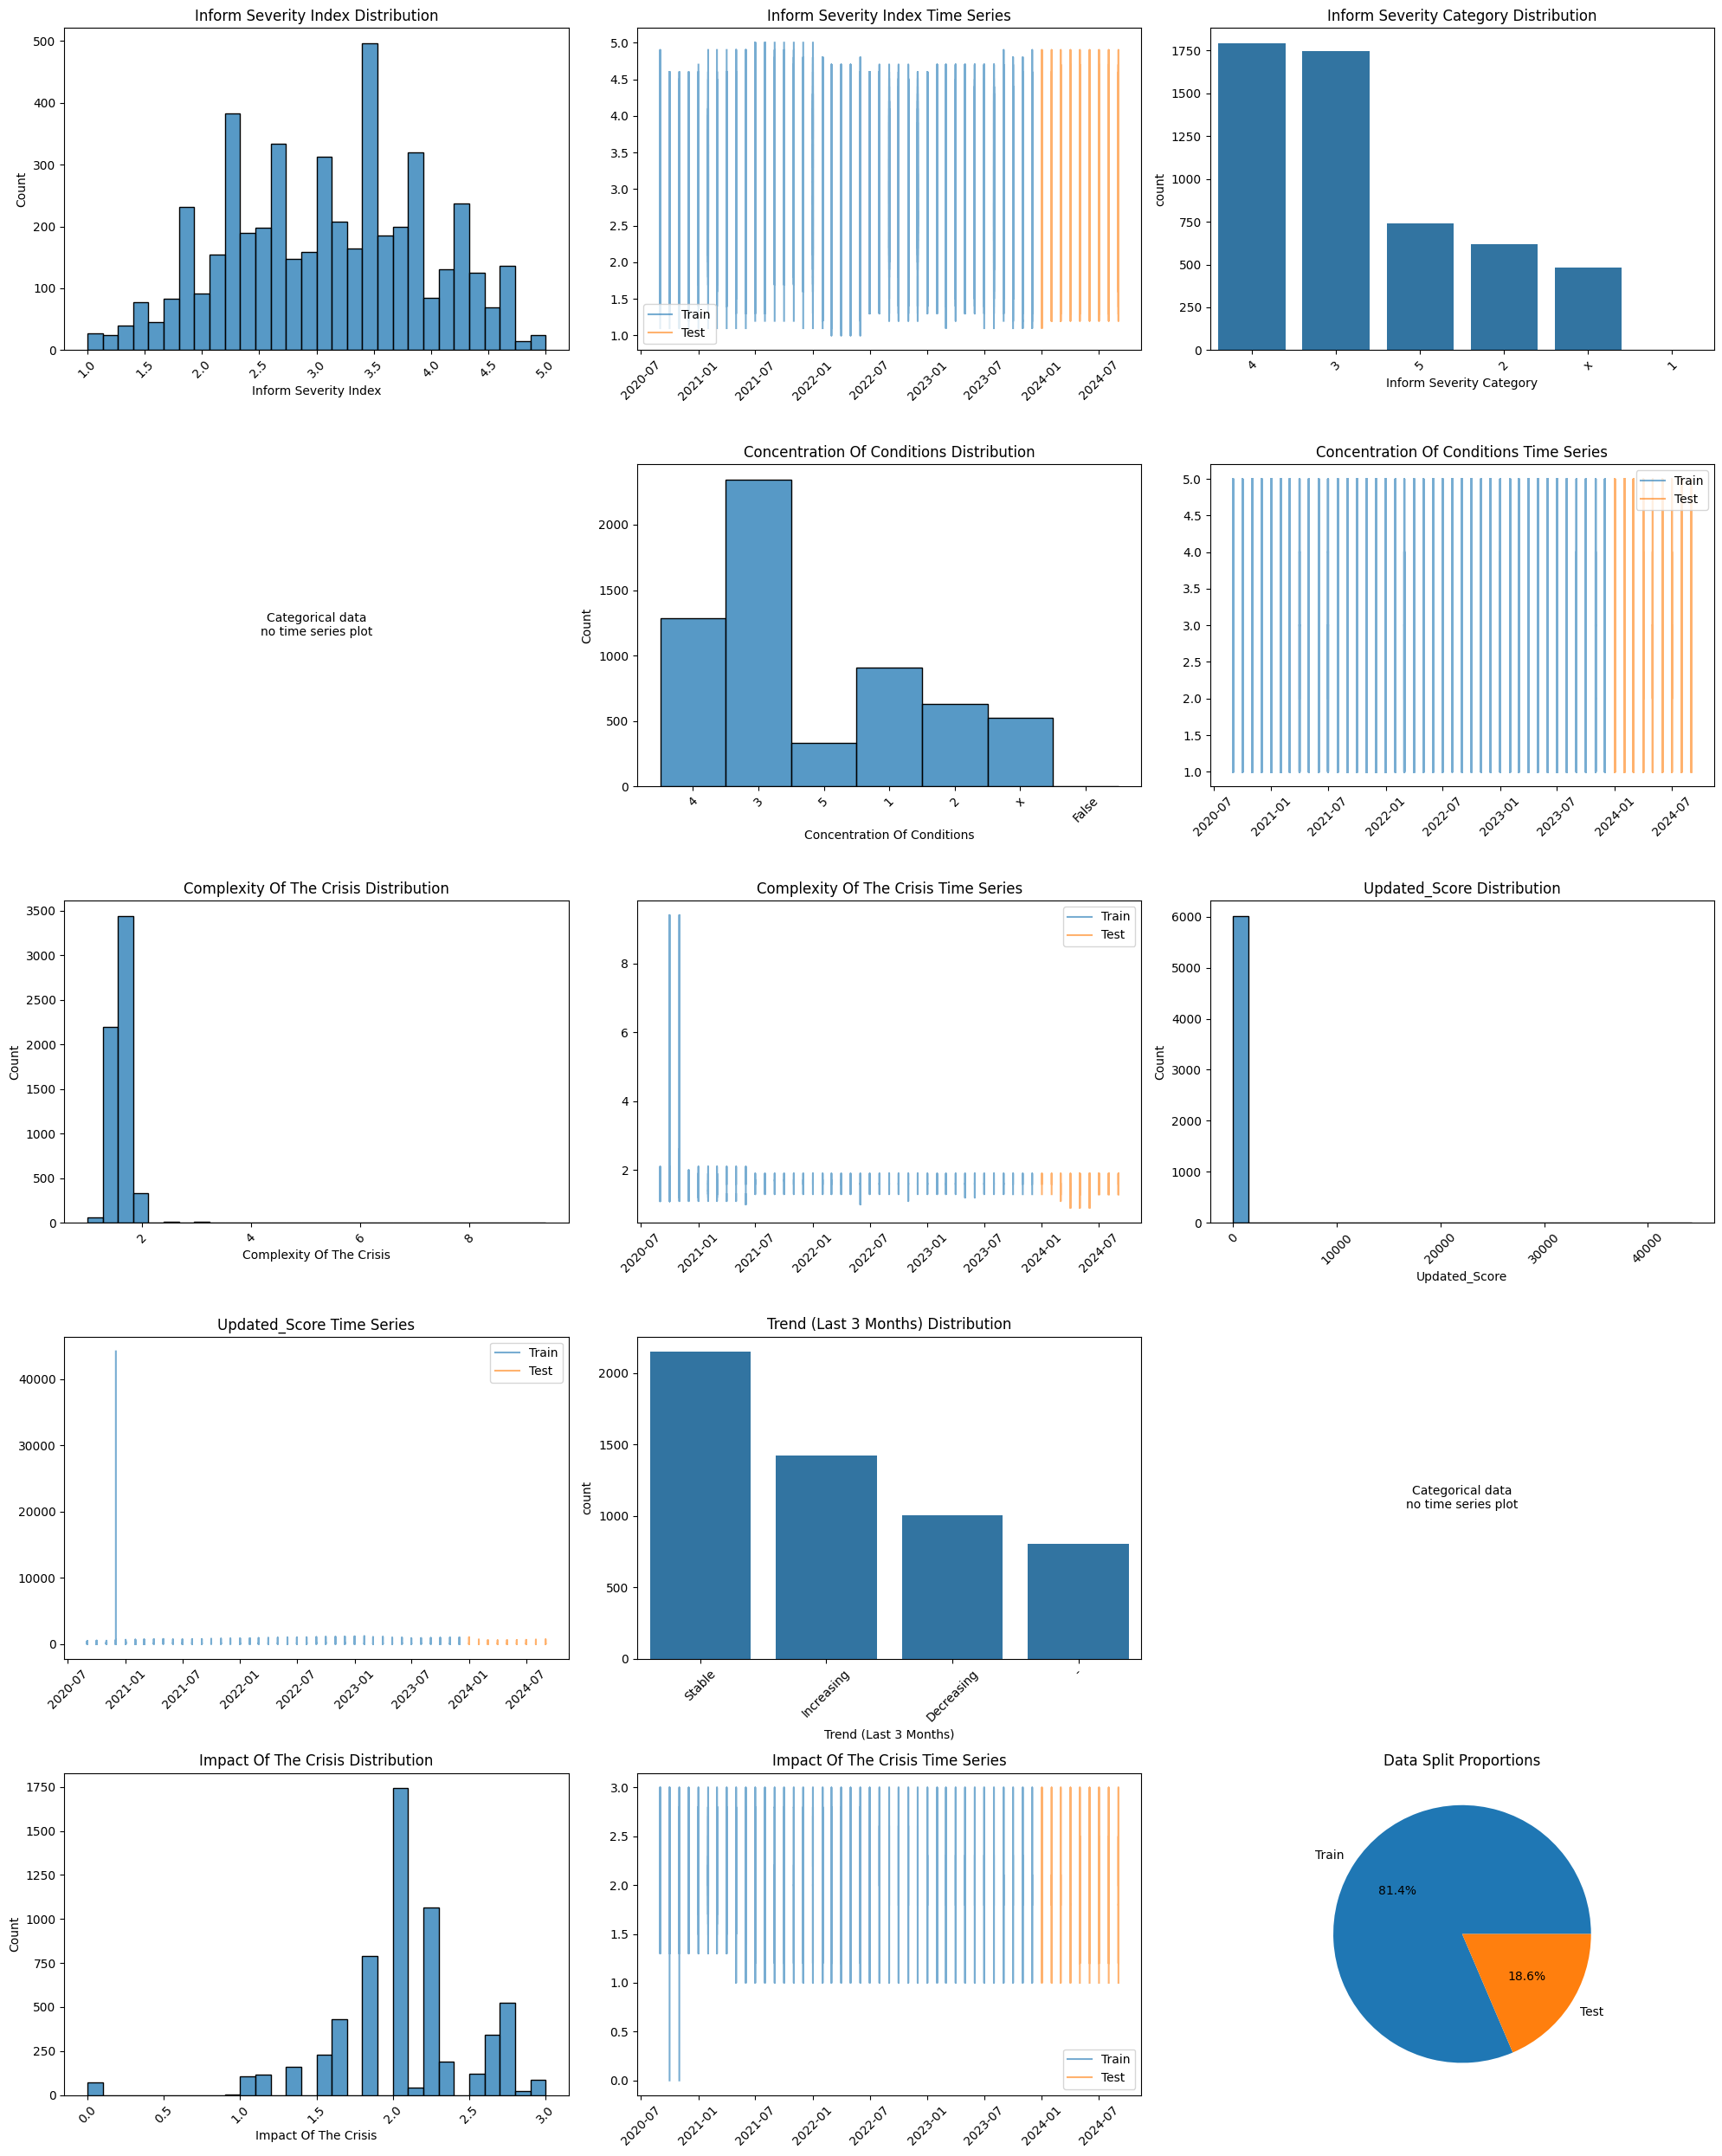


Data Distribution Statistics:
--------------------------------------------------
Total samples: 13262
Training samples: 10799 (81.4%)
Testing samples: 2463 (18.6%)

Target Variable Statistics:
--------------------------------------------------

Target: severity_level

Column: Inform Severity Index
Value counts:
 Inform Severity Index
3.5    250
3.4    246
2.3    219
3.2    208
3.7    200
Name: count, dtype: int64
Null values: 5902

Column: Inform Severity Category
Value counts:
 Inform Severity Category
4    1792
3    1745
5     739
2     617
x     483
Name: count, dtype: int64
Null values: 5419

Target: crisis_probability

Column: Concentration Of Conditions
Value counts:
 Concentration Of Conditions
3    2345
4    1282
1     907
2     628
x     527
Name: count, dtype: int64
Null values: 4775

Column: Complexity Of The Crisis
Value counts:
 Complexity Of The Crisis
1.6    2236
1.3    1278
1.7    1176
1.4     675
1.9     317
Name: count, dtype: int64
Null values: 4703

Column: Updated

In [6]:
def visualize_batch_data(train_df, test_df, config):
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    total_plots = sum(len(specs['columns']) * 2 for _, specs in config.targets.items()) + 1
    rows = (total_plots + 2) // 3
    cols = 3
    
    plt.figure(figsize=(20, 5*rows))
    subplot_idx = 1
    
    for target, specs in config.targets.items():
        for col in specs['columns']:
            # Convert string numbers to float where applicable
            if col in ['Inform Severity Index', 'Impact Of The Crisis']:
                train_df.loc[:, col] = pd.to_numeric(train_df[col], errors='coerce')
                test_df.loc[:, col] = pd.to_numeric(test_df[col], errors='coerce')
            
            # Distribution plot
            plt.subplot(rows, cols, subplot_idx)
            if col in ['Trend (Last 3 Months)', 'Inform Severity Category']:
                # Categorical plots
                sns.countplot(data=train_df, x=col, order=train_df[col].value_counts().index)
                plt.xticks(rotation=45)
            else:
                # Numerical plots
                sns.histplot(train_df[col].dropna(), bins=30)
            plt.title(f'{col} Distribution')
            plt.xticks(rotation=45)
            subplot_idx += 1
            
            # Time series plot
            plt.subplot(rows, cols, subplot_idx)
            if col in ['Trend (Last 3 Months)', 'Inform Severity Category']:
                # Skip time series for categorical data
                plt.text(0.5, 0.5, 'Categorical data\nno time series plot', 
                        ha='center', va='center')
                plt.axis('off')
            else:
                # Convert to numeric for time series plot
                train_values = pd.to_numeric(train_df[col], errors='coerce')
                test_values = pd.to_numeric(test_df[col], errors='coerce')
                plt.plot(train_df['date'], train_values, label='Train', alpha=0.6)
                plt.plot(test_df['date'], test_values, label='Test', alpha=0.6)
                plt.title(f'{col} Time Series')
                plt.legend()
                plt.xticks(rotation=45)
            subplot_idx += 1
    
    # Data split proportions
    plt.subplot(rows, cols, subplot_idx)
    splits = [len(train_df), len(test_df)]
    plt.pie(splits, labels=['Train', 'Test'], autopct='%1.1f%%')
    plt.title('Data Split Proportions')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nData Distribution Statistics:")
    print("-" * 50)
    print(f"Total samples: {len(df)}")
    print(f"Training samples: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"Testing samples: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")
    
    print("\nTarget Variable Statistics:")
    print("-" * 50)
    for target, specs in config.targets.items():
        print(f"\nTarget: {target}")
        for col in specs['columns']:
            print(f"\nColumn: {col}")
            print("Value counts:\n", train_df[col].value_counts().head())
            print("Null values:", train_df[col].isnull().sum())

# Call the function
visualize_batch_data(train_df, test_df, config)

# 3. Feature Engineering and Selection

## This section is divided into four parts:
1. Diadnostic code to check all feature & target groups
2. Analyzing column characteristics
3. Feature Engineering
4. Feature Selection & Importance (will be calculated soon!)

In [7]:
# Diagnostic code that checks all feature groups in the config
def analyze_data_quality(df, config):
    print("\nComprehensive Data Quality Analysis:")
    print("-" * 50)
    
    for group_name, features in config.feature_groups.items():
        print(f"\nFeature Group: {group_name}")
        print("-" * 30)
        
        for col in features:
            print(f"\nColumn: {col}")
            print("Data type:", df[col].dtype)
            # Check for non-numeric values
            non_numeric = df[col][~df[col].astype(str).str.replace('.', '').str.isnumeric()]
            print("Non-numeric values found:", non_numeric.unique())
            print("Count of non-numeric values:", len(non_numeric))
            # Show value distribution
            print("Value distribution:")
            print(df[col].value_counts().head())
            print("-" * 20)

# Run the analysis
analyze_data_quality(train_df, config)


Comprehensive Data Quality Analysis:
--------------------------------------------------

Feature Group: temporal_context
------------------------------

Column: YYYY_MM
Data type: object
Non-numeric values found: ['2020_09' '2020_10' '2020_11' '2020_12' '2021_01' '2021_02' '2021_03'
 '2021_04' '2021_05' '2021_06' '2021_07' '2021_08' '2021_09' '2021_10'
 '2021_11' '2021_12' '2022_01' '2022_02' '2022_03' '2022_04' '2022_05'
 '2022_06' '2022_07' '2022_08' '2022_09' '2022_10' '2022_11' '2022_12'
 '2023_01' '2023_02' '2023_03' '2023_04' '2023_05' '2023_06' '2023_07'
 '2023_08' '2023_09' '2023_10' '2023_11' '2023_12']
Count of non-numeric values: 10799
Value distribution:
YYYY_MM
2020_11    327
2020_10    303
2020_12    286
2023_10    281
2023_12    278
Name: count, dtype: int64
--------------------

Column: Country
Data type: object
Non-numeric values found: ['Afghanistan' 'Burundi' 'Burkina Faso' 'Bangladesh' 'Brazil' 'CAR'
 'China' 'Cameroon' 'DRC' 'Congo' 'Colombia' 'Costa Rica' 'Djibou

In [8]:
def analyze_column_characteristics(df, config):
    print("\nColumn Characteristics Analysis:")
    print("-" * 50)
    
    for group_name, features in config.feature_groups.items():
        print(f"\nFeature Group: {group_name}")
        print("-" * 30)
        
        for col in features:
            print(f"\nColumn: {col}")
            print("Current data type:", df[col].dtype)
            
            # Check for NaN values
            has_nan = df[col].isna().any()
            print("Contains NaN values:", has_nan)
            if has_nan:
                print("Number of NaN values:", df[col].isna().sum())
            
            # For numerical columns, show stats
            if df[col].dtype in ['float64', 'int64']:
                print("Statistical summary:")
                print(df[col].describe())
            else:
                unique_values = df[col].unique()[:5]
                print("Sample distinct values:", unique_values)
                
                special_chars = df[col].astype(str).str.contains('[^a-zA-Z0-9\s]').any()
                if special_chars:
                    print("Contains special characters: Yes")
            
            # Refined recommendations
            if col == 'YYYY_MM':
                print("Recommended: Convert to datetime for time series analysis")
            elif col in ['Country', 'Iso3', 'Region', 'Crisis Id', 'Crisis']:
                print("Recommended: Keep as categorical identifier")
            elif 'Date' in col:
                print("Recommended: Convert to datetime")
            elif df[col].dtype in ['float64', 'int64']:
                print("Recommended: Already numerical, handle missing values")
            elif df[col].dtype == 'object' and df[col].str.contains('x').any():
                print("Recommended: Replace 'x' with 0, convert to float")
            else:
                print("Recommended: Evaluate for categorical encoding")
                
            print("-" * 20)

# Run the analysis
analyze_column_characteristics(train_df, config)


Column Characteristics Analysis:
--------------------------------------------------

Feature Group: temporal_context
------------------------------

Column: YYYY_MM
Current data type: object
Contains NaN values: False
Sample distinct values: ['2020_09' '2020_10' '2020_11' '2020_12' '2021_01']
Contains special characters: Yes
Recommended: Convert to datetime for time series analysis
--------------------

Column: Country
Current data type: object
Contains NaN values: True
Number of NaN values: 116
Sample distinct values: ['Afghanistan' 'Burundi' 'Burkina Faso' 'Bangladesh' 'Brazil']
Contains special characters: Yes
Recommended: Keep as categorical identifier
--------------------

Column: Iso3
Current data type: object
Contains NaN values: True
Number of NaN values: 4775
Sample distinct values: ['Afg' 'Bdi' 'Bfa' 'Bgd' 'Bra']
Contains special characters: Yes
Recommended: Keep as categorical identifier
--------------------

Column: Region
Current data type: object
Contains NaN values: Tru

In [12]:
from scripts.feature_engineering import FeatureEngineering
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import re

def clean_feature_names(X):
    X = X.copy()
    def clean_name(name):
        name = str(name)
        name = re.sub(r'[^A-Za-z0-9]+', '_', name)
        name = re.sub(r'_{2,}', '_', name)
        name = name.strip('_')
        if not name[0].isalpha():
            name = 'f_' + name
        return name
    
    clean_columns = [clean_name(col) for col in X.columns]
    X.columns = clean_columns
    return X

class CustomFeatureEngineering(FeatureEngineering):
    def __init__(self, config):
        super().__init__(config)
        self.label_encoders = {}
        self.null_values = ['x', 'X', 'Missing', 'missing', 'False', 'false', '-', 'NA', 'na', 'N/A', 'n/a']
        self.categorical_cols = ['Country', 'Iso3', 'Region', 'Crisis Id', 'Crisis']
        self.identifier_cols = []
        self.date_formats = {
            'standard': '%Y-%m-%d',
            'datetime': '%Y-%m-%d %H:%M:%S',
            'year_month': '%Y_%m'
        }
        
    def process_features(self, df: pd.DataFrame):
        self.identifier_cols = [col for col in df.columns if any(x in col for x in ['Total population', 'Helper'])]
        df = df.copy()
        processed_df = df.copy()
        
        # Process each feature group
        for group_name, features in self.config.feature_groups.items():
            processed_df = self._process_feature_group(processed_df, features, group_name)
            
        # Create derived features
        temporal_features = self._create_temporal_features(processed_df)
        encoded_features = self._encode_categorical_features(temporal_features)
        
        # Additional feature derivation
        final_features = self._derive_additional_features(encoded_features)
        
        return {
            'base': processed_df,
            'temporal': temporal_features,
            'encoded': encoded_features,
            'final': final_features
        }
    
    def _process_feature_group(self, df, features, group_name):
        df = df.copy()
        
        for col in features:
            if col not in df.columns:
                continue
                
            if col in self.categorical_cols or col in self.identifier_cols:
                continue
            elif 'Date' in col:
                df[col] = self._parse_dates(df[col])
            elif col == 'YYYY_MM':
                df[col] = pd.to_datetime(df[col], format=self.date_formats['year_month'])
            else:
                df[col] = self._convert_numeric(df[col])
                
        return df
    
    def _parse_dates(self, series):
        for format_name, date_format in self.date_formats.items():
            try:
                return pd.to_datetime(series, format=date_format)
            except:
                continue
        return pd.to_datetime(series, errors='coerce')
    
    def _convert_numeric(self, series):
        return pd.to_numeric(series.replace(self.null_values, 0), errors='coerce').fillna(0)
    
    def _create_temporal_features(self, df):
        df = df.copy()
        df['datetime'] = pd.to_datetime(df['YYYY_MM'], format=self.date_formats['year_month'])
        
        # Extract temporal components
        df['year'] = df['datetime'].dt.year
        df['month'] = df['datetime'].dt.month
        df['quarter'] = df['datetime'].dt.quarter
        df['year_month'] = df['datetime'].dt.strftime('%Y%m')
        df['month_of_quarter'] = df['month'] % 3 + 1
        
        return df
    
    def _encode_categorical_features(self, df):
        df = df.copy()
        categorical_cols = [col for col in self.categorical_cols if col in df.columns]
        
        for col in categorical_cols:
            if col not in self.label_encoders:
                self.label_encoders[col] = LabelEncoder()
            df[f'{col}_encoded'] = self.label_encoders[col].fit_transform(df[col].astype(str))
            
        return df
    
    def _derive_additional_features(self, df):
        df = df.copy()
        
        # Add any domain-specific feature combinations here
        numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
        
        # Calculate rolling statistics for numeric columns
        for col in numeric_cols:
            df[f'{col}_rolling_mean'] = df.groupby('Crisis Id')[col].transform(
                lambda x: x.rolling(window=3, min_periods=1).mean()
            )
            
        return df

class CustomDataPreprocessor:
    def __init__(self, config):
        self.config = config
        self.numerical_imputer = SimpleImputer(strategy='constant', fill_value=0)
        self.categorical_imputer = SimpleImputer(strategy='constant', fill_value='missing')

    def process_data(self, data_dict):
        processed = {}
        for key, df in data_dict.items():
            if isinstance(df, pd.DataFrame):
                processed[key] = self.handle_missing_values(df)
        return processed

    def handle_missing_values(self, df):
        df = df.copy()
        
        # Handle numerical columns
        numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
        if len(numerical_cols) > 0:
            df[numerical_cols] = self.numerical_imputer.fit_transform(df[numerical_cols])
            
        # Handle categorical columns
        categorical_cols = df.select_dtypes(include=['object']).columns
        if len(categorical_cols) > 0:
            df[categorical_cols] = self.categorical_imputer.fit_transform(df[categorical_cols])
            
        return df

def process_features(df, config):
    feature_engineer = CustomFeatureEngineering(config)
    preprocessor = CustomDataPreprocessor(config)
    
    engineered_features = feature_engineer.process_features(df)
    processed_data = preprocessor.process_data(engineered_features)
    
    return processed_data

def detailed_inspection(processed_data):
    print("\nDetailed Data Processing Results:")
    print("-" * 50)
    
    for key, df in processed_data.items():
        print(f"\nDataset Type: {key}")
        print(f"Shape: {df.shape}")
        
        print("\nFeature Types Summary:")
        print(df.dtypes.value_counts())
        
        print("\nNumerical Columns Statistics:")
        numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
        if len(numeric_cols) > 0:
            print(df[numeric_cols].describe())
        
        print("\nMissing Values Summary:")
        missing_vals = df.isnull().sum()
        if missing_vals.any():
            print(missing_vals[missing_vals > 0])
        else:
            print("No missing values found")
        
        print("-" * 50)

# Run processing and inspection
train_processed = process_features(train_df, config)
detailed_inspection(train_processed)


Detailed Data Processing Results:
--------------------------------------------------

Dataset Type: base
Shape: (10799, 399)

Feature Types Summary:
object            317
float64            78
datetime64[ns]      4
Name: count, dtype: int64

Numerical Columns Statistics:
        Empowerment  Bti - Democracy Status  Trust In Society  \
count  10799.000000            10799.000000      10799.000000   
mean       1.506528                1.436874          1.499643   
std        1.627075                1.456608          1.511796   
min        0.000000                0.000000          0.000000   
25%        0.000000                0.000000          0.000000   
50%        1.100000                1.400000          1.500000   
75%        2.900000                2.800000          2.800000   
max        5.000000                4.300000          4.450000   

       Ethnic Fractionalisation  Size Of Excluded Ethnic Groups  \
count              10799.000000                    10799.000000   
mean   

# 3.5 Hyperparameter Tuning ** (Experimental)**

In [ ]:
param_grids = {
    'lightgbm': {
        'n_estimators': [500, 1000, 1500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'num_leaves': [31, 63, 127]
    },
    'catboost': {
        'iterations': [500, 1000, 1500],
        'learning_rate': [0.01, 0.05, 0.1],
        'depth': [4, 6, 8]
    },
    'lstm': {
        'hidden_size': [32, 50, 64],
        'num_layers': [1, 2],
        'dropout': [0.1, 0.2, 0.3]
    }
}

best_params = {}
for target in config.targets:
    best_params[target] = {}
    for model_type, param_grid in param_grids.items():
        print(f"Tuning {model_type} for {target}...")

        if model_type in ['lightgbm', 'catboost']:
            model_class = model.models[target][model_type].__class__
            grid_search = GridSearchCV(
                estimator=model_class(),
                param_grid=param_grid,
                cv=5,
                scoring='neg_mean_squared_error',
                n_jobs=-1
            )
            grid_search.fit(X_train[selected_features[target]], y_train[target])
            best_params[target][model_type] = grid_search.best_params_

        elif model_type == 'lstm':
            best_loss = float('inf')
            best_lstm_params = {}

            for params in ParameterGrid(param_grid):
                model.models[target]['lstm'].set_params(**params)
                val_loss = trainer.validate_lstm(X_train, y_train, target)

                if val_loss < best_loss:
                    best_loss = val_loss
                    best_lstm_params = params

            best_params[target]['lstm'] = best_lstm_params

model.update_parameters(best_params)
print("\nBest parameters found:")
for target, params in best_params.items():
    print(f"\n{target}:")
    for model_type, model_params in params.items():
        print(f"{model_type}: {model_params}")

# 4. Model Training

In [ ]:
# Initialize model
model = CrisisPredictor(config)
trainer = ModelTrainer(config, model)

# Train model
history = trainer.train_model(X_train, y_train)

# Visualize training history
visualizer = Visualizer(config)
visualizer.plot_training_history(history)

# 5. Model Evaluation and Uncertainty Estimation

In [ ]:
# Prepare test data
X_test, y_test = data_loader.prepare_features_targets(test_processed)

# Evaluate model
evaluator = ModelEvaluator(config)
metrics = evaluator.evaluate_predictions(y_test, model.forward(X_test))

# Estimate uncertainty
uncertainty_estimator = UncertaintyEstimator(config)
predictions, uncertainties = uncertainty_estimator.monte_carlo_dropout(model, X_test)

# Visualize results
visualizer.plot_results(test_df['date'], predictions, metrics)

# 6. Save Model and Results

In [ ]:
persistence = ModelPersistence(config)
metadata = {
    'training_history': history,
    'feature_importance': feature_selector.feature_importance,
    'performance_metrics': metrics
}
persistence.save_model(model, metadata, 'v1.0')
print("Model and results saved successfully")